In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv('Planets_dataset.csv', header=27)

In [7]:
def log_errs(val, errs, err_lower=None):
    err_lower = errs if err_lower is None else np.abs(err_lower)
    upper = np.log10(val+errs)
    mask = (val - errs <= 0)
    lower = np.log10(val-err_lower)
    lower[mask] = -np.inf
    logerr = 0.5*(upper-lower)
    return logerr

In [48]:
x = np.log10(df['pl_rade'].values)
y = np.log10(df['pl_masse'].values)
xerr = log_errs(df['pl_rade'].values, df['pl_radeerr1'].values, df['pl_radeerr2'].values)
yerr = log_errs(df['pl_masse'].values, df['pl_masseerr1'].values, df['pl_masseerr2'].values)

xmask = ~np.isinf(xerr)
ymask = ~(np.isinf(yerr) | np.isnan(yerr))
mask = xmask & ymask

/tmp/ipykernel_4660/2343081272.py:5: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-err_lower)
/tmp/ipykernel_4660/2343081272.py:5: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-err_lower)


<ErrorbarContainer object of 3 artists>

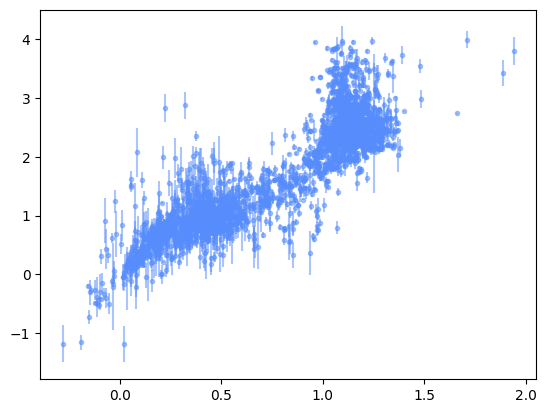

In [49]:
plt.errorbar(x[mask], y[mask], yerr=yerr[mask], fmt='o', alpha=0.5, ms=3)

In [50]:
N = int(np.sum(ymask))
X = x[ymask].reshape(-1,1)
y = y[ymask].reshape(-1,1)
yerr = yerr[ymask].reshape(-1,1)

In [51]:
def kernel(a, b, l=1, sigm_f=1):
    sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    return sigm_f**2 * np.exp(-.5 * (1/l**2) * sqdist)

In [52]:
#Cholesky decomposition is used instead of directly inverting the the matrix
K = kernel(X, X)
L = np.linalg.cholesky(K + yerr.flatten()*np.eye(N))

In [53]:
# points we're going to make predictions at.
n=50
Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)

In [54]:
# mean at our test points.
Lk = np.linalg.solve(L, kernel(X, Xtest))
mu = np.dot(Lk.T, np.linalg.solve(L, y))

In [55]:
# variance at our test points.
K_ = kernel(Xtest, Xtest)
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
s = np.sqrt(s2)

In [56]:
#draw samples from the prior distribution
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n))
f_prior = np.dot(L, np.random.normal(size=(n,5)))

In [57]:
#draw samples from the posterior distribution
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))

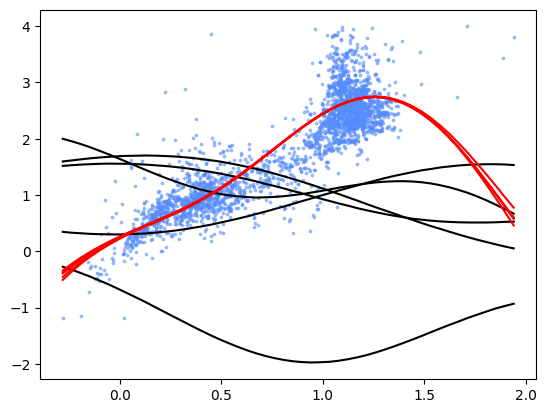

In [59]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_prior, 'k-', label='prior')
plt.plot(Xtest, f_post, 'r-', label='posterior')